In [7]:
# ========================
# 字号统一控制（只需改这里）
# ========================
FONT_SIZE_BASE = 17      # 基础字号
FONT_SIZE_LABEL = 18     # 坐标轴标签
FONT_SIZE_TICK = 16      # 刻度字号
FONT_SIZE_ANNOT = 16    # 数值标注字号（如果后续需要）

## london 数据提取

动物名为 Robin Shrew Mouse

In [1]:
import pandas as pd

# 读取原始数据
df = pd.read_csv("../data/electricity.csv")

# 需要保留的前缀
valid_prefixes = {"Robin", "Shrew", "Mouse"}

# 第一列（时间戳）强制保留
timestamp_col = df.columns[0]

# 根据列名筛选
selected_columns = [
    col for col in df.columns
    if col == timestamp_col or col.split("_")[0] in valid_prefixes
]

# 构建新 DataFrame
df_filtered = df[selected_columns]

# 保存为新的 CSV 文件（同级目录）
df_filtered.to_csv("../data/electricityLondon.csv", index=False)

print(f"已成功生成 electricityLondon.csv，共保留 {len(selected_columns)-1} 个负荷列")


已成功生成 electricityLondon.csv，共保留 68 个负荷列


## 统计各地点的节点次数

Univ. College London (UCL) : robin

UK Parliment : shrew

Ormand Street Hospital : mouse

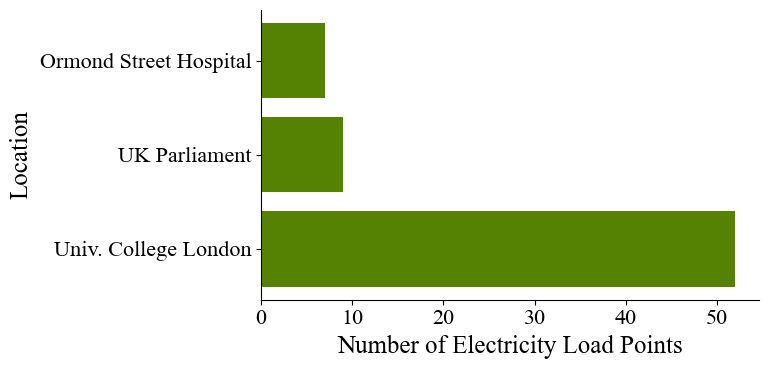

In [56]:
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("../data/electricityLondon.csv")

# 提取负荷列（去掉时间戳）
data_columns = df.columns[1:]

# 统计每一类的列数
count_robin = sum(col.split("_")[0] == "Robin" for col in data_columns)
count_shrew = sum(col.split("_")[0] == "Shrew" for col in data_columns)
count_mouse = sum(col.split("_")[0] == "Mouse" for col in data_columns)

# 映射到机构名称
labels = [
    "Univ. College London",
    "UK Parliament",
    "Ormond Street Hospital"
]

counts = [count_robin, count_shrew, count_mouse]

# 使用 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = FONT_SIZE_BASE

# 创建图像
fig, ax = plt.subplots(figsize=(8, 4))

# 牛油果绿色
avocado_green = "#568203"

# 绘制水平柱状图
ax.barh(labels, counts, color=avocado_green)

# 坐标轴标签（可控字号）
ax.set_xlabel(
    "Number of Electricity Load Points",
    fontsize=FONT_SIZE_LABEL
)
ax.set_ylabel(
    "Location",
    fontsize=FONT_SIZE_LABEL
)

# 刻度字号
ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)

# 关闭背景网格
ax.grid(False)

# 去除多余边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## 统计各功能节点出现的次数

primary


=== Column Name Statistics (Second Word) ===

When the first word is 'Robin', the possible second words and their counts are:
  - assembly: 1
  - education: 22
  - lodging: 10
  - office: 17
  - public: 2

When the first word is 'Shrew', the possible second words and their counts are:
  - office: 9

When the first word is 'Mouse', the possible second words and their counts are:
  - health: 5
  - lodging: 1
  - science: 1



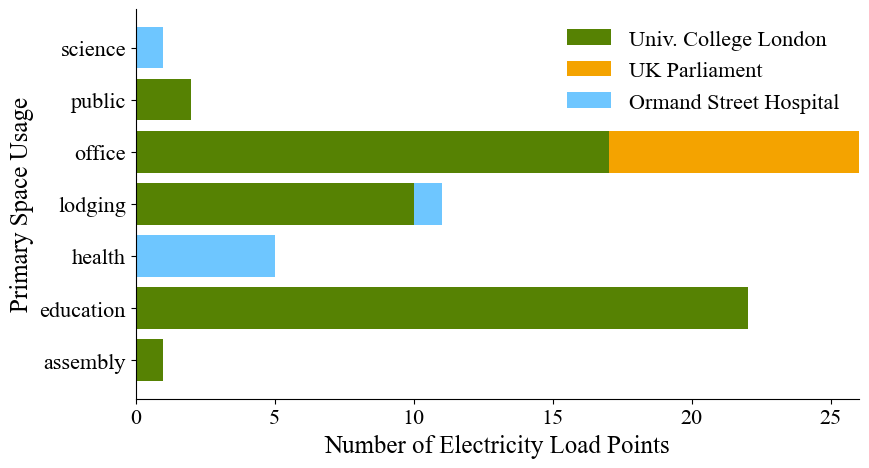

In [58]:
from collections import defaultdict

# ========================
# 统计第二个单词的出现情况
# ========================

# 仅使用负荷列
df = pd.read_csv("../data/electricityLondon.csv")
columns = df.columns[1:]

# 结构：stats[first_word][second_word] = count
stats = {
    "Robin": defaultdict(int),
    "Shrew": defaultdict(int),
    "Mouse": defaultdict(int)
}

# 遍历列名
for col in columns:
    parts = col.split("_")
    if len(parts) >= 2:
        first, second = parts[0], parts[1]
        if first in stats:
            stats[first][second] += 1

# 打印统计结果
print("\n=== Column Name Statistics (Second Word) ===\n")

for first_word, second_dict in stats.items():
    print(f"When the first word is '{first_word}', "
          f"the possible second words and their counts are:")
    for second_word, count in sorted(second_dict.items()):
        print(f"  - {second_word}: {count}")
    print()


# =================================
# 汇总所有第二个单词（不区分第一个单词）
# =================================

all_second_words = set()
for d in stats.values():
    all_second_words.update(d.keys())

# 按字母排序（图更稳定）
all_second_words = sorted(all_second_words)

# 分别统计三类贡献
robin_counts = [stats["Robin"].get(w, 0) for w in all_second_words]
shrew_counts = [stats["Shrew"].get(w, 0) for w in all_second_words]
mouse_counts = [stats["Mouse"].get(w, 0) for w in all_second_words]


# ========================
# 颜色定义
# ========================
color_robin = "#568203"   # Avocado green
color_shrew = "#F4A300"   # Orange-yellow
color_mouse = "#6EC6FF"   # Sky blue

# 创建图像
fig, ax = plt.subplots(figsize=(9, 5))

# 左侧累积位置
left_robin = [0] * len(all_second_words)
left_shrew = robin_counts

left_mouse = [
    r + s for r, s in zip(robin_counts, shrew_counts)
]

# 绘制堆叠水平柱状图
ax.barh(
    all_second_words,
    robin_counts,
    color=color_robin,
    label="Univ. College London"
)

ax.barh(
    all_second_words,
    shrew_counts,
    left=left_shrew,
    color=color_shrew,
    label="UK Parliament"
)

ax.barh(
    all_second_words,
    mouse_counts,
    left=left_mouse,
    color=color_mouse,
    label="Ormand Street Hospital"
)

# 坐标轴标签
ax.set_xlabel(
    "Number of Electricity Load Points",
    fontsize=FONT_SIZE_LABEL
)
ax.set_ylabel(
    "Primary Space Usage",
    fontsize=FONT_SIZE_LABEL
)

# 刻度字号
ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)

# 图例
ax.legend(
    fontsize=FONT_SIZE_TICK,
    frameon=False
)

# 关闭背景网格
ax.grid(False)

# 去除多余边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

sub_primary

In [49]:
# 得到 sub_primarysSpaceUsage

# 读取csv文件
df = pd.read_csv("../data/metadata.csv")

# 构建新的列sub_primarysSpaceUsage
def construct_new_column(row):
    # 如果primaryspaceusage或sub_primaryspaceusage是空值或非字符串，返回空字符串
    if not isinstance(row['primaryspaceusage'], str) or not isinstance(row['sub_primaryspaceusage'], str):
        return ''
    primary_first_word = row['primaryspaceusage'].split()[0]  # 取primaryspaceusage中第一个单词
    primary_first_letter = primary_first_word[0].upper()     # 取第一个字母并大写
    sub_primary = row['sub_primaryspaceusage']               # 取sub_primaryspaceusage的值
    return f"{primary_first_letter}_{sub_primary}"           # 拼接形成新的值

# 应用到每一行
df['sub_primarysSpaceUsage'] = df.apply(construct_new_column, axis=1)

# 保存为新的csv文件
df.to_csv("../data/metadata.csv", index=False)

print("新列已添加并保存为../data/metadata.csv")

新列已添加并保存为../data/metadata.csv



=== sub_primarysSpaceUsage Statistics by First Word ===

When the first word is 'Robin', the possible sub_primarysSpaceUsage values and their counts are:
  - A_Gymnasium: 1
  - E_College Classroom: 3
  - E_College Laboratory: 19
  - L_Dormitory: 10
  - O_Office: 17
  - P_Library: 2

When the first word is 'Shrew', the possible sub_primarysSpaceUsage values and their counts are:
  - O_Office: 9

When the first word is 'Mouse', the possible sub_primarysSpaceUsage values and their counts are:
  - H_Hospital: 5
  - L_Hotel: 1
  - S_Laboratory: 1



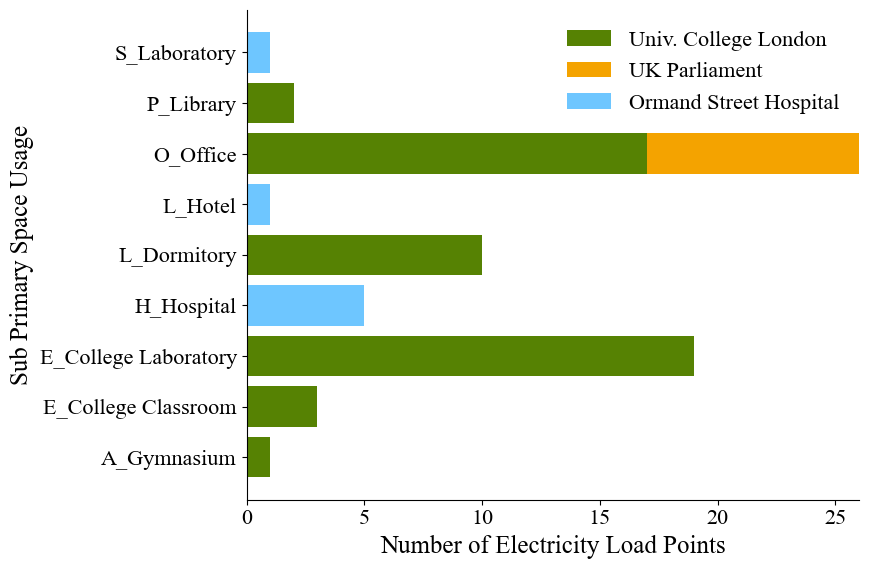

In [57]:
# ========================
# 读取数据
# ========================
electricity_df = pd.read_csv("../data/electricityLondon.csv")
metadata_df = pd.read_csv("../data/metadata.csv")

# 仅保留负荷列名（去掉时间戳）
load_columns = electricity_df.columns[1:]

# 构建 building_id -> sub_primarysSpaceUsage 映射
building_to_usage = dict(
    zip(metadata_df["building_id"], metadata_df["sub_primarysSpaceUsage"])
)


# =================================================
# stats[first_word][space_usage] = count
# =================================================
stats_usage = {
    "Robin": defaultdict(int),
    "Shrew": defaultdict(int),
    "Mouse": defaultdict(int)
}

# 遍历 electricityLondon.csv 中的列
for col in load_columns:
    parts = col.split("_")
    if len(parts) >= 1:
        first_word = parts[0]
        if first_word in stats_usage:
            # 通过 building_id 查 metadata
            space_usage = building_to_usage.get(col)
            if pd.notna(space_usage):
                stats_usage[first_word][space_usage] += 1

print("\n=== sub_primarysSpaceUsage Statistics by First Word ===\n")

for first_word, usage_dict in stats_usage.items():
    print(
        f"When the first word is '{first_word}', "
        f"the possible sub_primarysSpaceUsage values and their counts are:"
    )
    for usage, count in sorted(usage_dict.items()):
        print(f"  - {usage}: {count}")
    print()


# ==========================================
# 汇总所有可能的 sub_primarysSpaceUsage
# ==========================================
all_usages = set()
for d in stats_usage.values():
    all_usages.update(d.keys())

# 排序（保证图稳定）
all_usages = sorted(all_usages)

# 分别统计三类贡献
robin_counts = [stats_usage["Robin"].get(u, 0) for u in all_usages]
shrew_counts = [stats_usage["Shrew"].get(u, 0) for u in all_usages]
mouse_counts = [stats_usage["Mouse"].get(u, 0) for u in all_usages]


# ========================
# 绘制图像
# ========================
color_robin = "#568203"   # Avocado green
color_shrew = "#F4A300"   # Orange-yellow
color_mouse = "#6EC6FF"   # Sky blue

# 创建图像
fig, ax = plt.subplots(figsize=(9, 6))

# 堆叠起始位置
left_robin = [0] * len(all_usages)
left_shrew = robin_counts
left_mouse = [r + s for r, s in zip(robin_counts, shrew_counts)]

# 绘制堆叠水平柱状图
ax.barh(
    all_usages,
    robin_counts,
    color=color_robin,
    label="Univ. College London"
)

ax.barh(
    all_usages,
    shrew_counts,
    left=left_shrew,
    color=color_shrew,
    label="UK Parliament"
)

ax.barh(
    all_usages,
    mouse_counts,
    left=left_mouse,
    color=color_mouse,
    label="Ormand Street Hospital"
)

# 坐标轴标签
ax.set_xlabel(
    "Number of Electricity Load Points",
    fontsize=FONT_SIZE_LABEL
)
ax.set_ylabel(
    "Sub Primary Space Usage",
    fontsize=FONT_SIZE_LABEL
)

# 刻度字号
ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)

# 图例
ax.legend(
    fontsize=FONT_SIZE_TICK,
    frameon=False
)

# 无背景网格
ax.grid(False)

# 去除多余边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()